# 03 - Forecasting Experiments

## Financial Portfolio Forecasting & Anomaly Detection


### Purpose

The goal of this notebook is to run forecasting experiments on financial asset price data.

We will:

- Load and clean the financial asset dataset
- Prepare time series features
- Create train-test split
- Build baseline forecasting models
- Train machine learning forecasting model
- Compare forecasting metrics
- Visualize actual vs predicted prices
- Save experiment outputs

### Dataset Columns

Expected columns:

| Column | Description |
|---|---|
| date | Date of asset price record |
| asset | Asset name |
| price | Asset price |

Raw file path:

```text
data/raw/financial_portfolio_data.csv

## 1. Import Required Libraries

We import libraries for:

- Data loading
- Data cleaning
- Feature engineering
- Forecasting experiments
- Model evaluation
- Visualization

In [36]:
from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Project Paths

This notebook reads the raw dataset and saves experiment outputs.

Input:

```text
data/raw/financial_portfolio_data.csv

Outputs:

- reports/tables/
- reports/figures/
- outputs/
- models/

In [37]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "financial_portfolio_data.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Raw data exists:", RAW_DATA_PATH.exists())

Project root: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection
Raw data path: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\data\raw\financial_portfolio_data.csv
Raw data exists: True


## 3. Load Dataset

The uploaded dataset should be renamed as:

```text
financial_portfolio_data.csv

and placed inside:

data/raw/

In [38]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {RAW_DATA_PATH}. "
        "Please place financial_portfolio_data.csv inside data/raw/."
    )

df = pd.read_csv(RAW_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (500, 3)


,Date,Asset,Price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 4. Standardize Column Names

The original CSV may contain:

- `Date`
- `Asset`
- `Price`

We convert them to:

- `date`
- `asset`
- `price`

In [39]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Columns:")
print(df.columns.tolist())

df.head()

Columns:
['date', 'asset', 'price']


,date,asset,price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 5. Validate Required Columns

The forecasting notebook requires:

- `date`
- `asset`
- `price`

In [40]:
required_columns = ["date", "asset", "price"]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")

All required columns are available.


## 6. Clean Dataset

We clean the dataset by:

- Converting date to datetime
- Converting price to numeric
- Removing missing values
- Removing negative prices
- Sorting by asset and date

In [41]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["date", "asset", "price"])
df = df[df["price"] >= 0]

df = df.sort_values(["asset", "date"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Assets:", df["asset"].unique())

df.head()

Cleaned shape: (500, 3)
Date range: 2023-01-02 00:00:00 to 2023-12-31 00:00:00
Assets: <ArrowStringArray>
['Bond A', 'Bond B', 'Commodity A', 'Stock A', 'Stock B']
Length: 5, dtype: str


,date,asset,price
0,2023-01-03,Bond A,198.6100
1,2023-01-04,Bond A,142.2400
2,2023-01-08,Bond A,146.5800
3,2023-01-11,Bond A,473.2000
4,2023-01-13,Bond A,376.5700


## 7. Dataset Summary

Before modeling, we summarize:

- Total records
- Number of assets
- Date range
- Price range

In [42]:
dataset_summary = {
    "total_records": len(df),
    "total_assets": df["asset"].nunique(),
    "assets": sorted(df["asset"].unique().tolist()),
    "start_date": str(df["date"].min()),
    "end_date": str(df["date"].max()),
    "average_price": float(df["price"].mean()),
    "minimum_price": float(df["price"].min()),
    "maximum_price": float(df["price"].max()),
}

dataset_summary_df = pd.DataFrame([dataset_summary])
dataset_summary_df

,total_records,total_assets,assets,start_date,end_date,average_price,minimum_price,maximum_price
0,500,5,"[Bond A, Bond B, Commodity A, Stock A, Stock B]",2023-01-02 00:00:00,2023-12-31 00:00:00,281.3577,50.2000,499.7900


## 8. Asset-Level Summary

We check how many records each asset has.

This is important because forecasting models need enough historical data for each asset.

In [43]:
asset_summary = (
    df.groupby("asset")
    .agg(
        record_count=("price", "count"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        average_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        price_std=("price", "std")
    )
    .reset_index()
    .sort_values("record_count", ascending=False)
)

asset_summary

,asset,record_count,start_date,end_date,average_price,min_price,max_price,price_std
1,Bond B,110,2023-01-07,2023-12-30,294.4699,51.0400,498.2600,131.6930
0,Bond A,109,2023-01-03,2023-12-30,265.8024,50.2000,497.5900,132.7395
2,Commodity A,106,2023-01-03,2023-12-31,280.2518,63.8600,499.7600,133.9463
3,Stock A,101,2023-01-02,2023-12-25,284.8642,51.4300,496.6000,125.3389
4,Stock B,74,2023-01-10,2023-12-22,281.5776,51.3000,499.7900,131.6725


## 9. Visualize Price Trend

This chart shows asset price movement over time.

It helps us understand whether the forecasting problem has trend, volatility, or sudden changes.

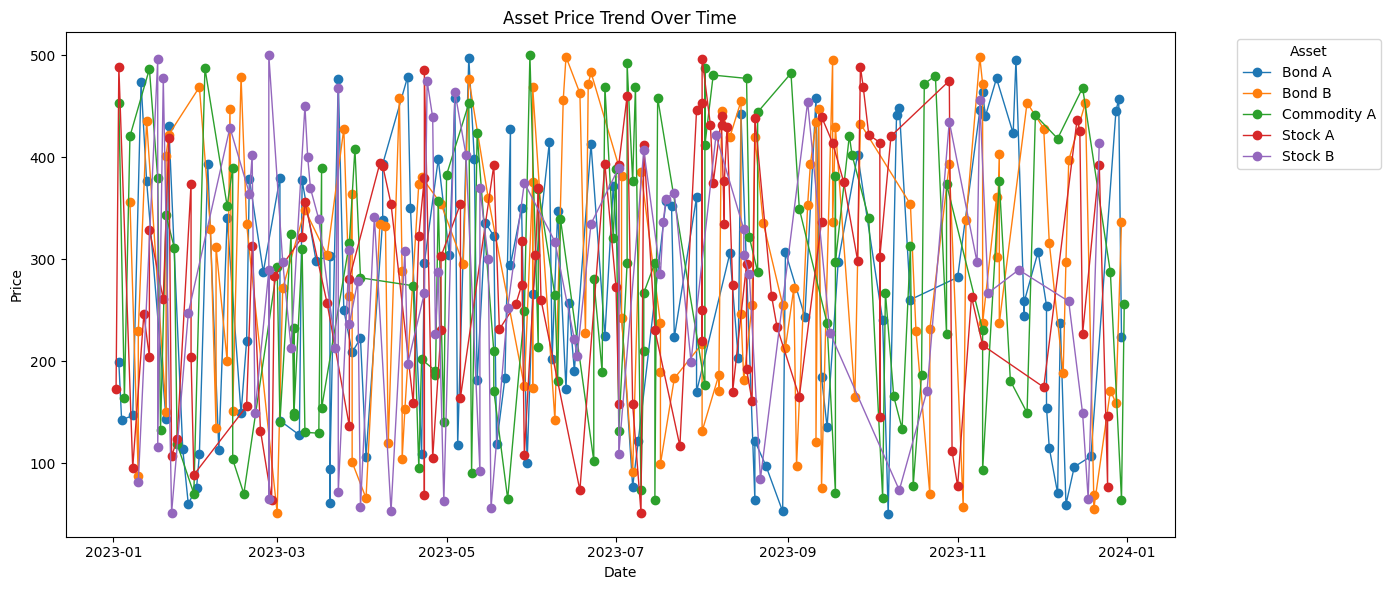

In [44]:
plt.figure(figsize=(14, 6))

for asset in df["asset"].unique():
    asset_data = df[df["asset"] == asset].sort_values("date")
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        linewidth=1,
        marker="o",
        label=asset
    )

plt.title("Asset Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(title="Asset", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_asset_price_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Create Forecasting Features

For machine learning forecasting, we create:

- Calendar features
- Daily return
- Lag features
- Rolling mean features
- Rolling standard deviation features

These features help models learn time-based price patterns.

In [45]:
def create_forecasting_features(dataframe):
    """
    Create forecasting features for asset price prediction.

    Args:
        dataframe (pd.DataFrame): Cleaned financial dataframe.

    Returns:
        pd.DataFrame: Feature-engineered dataframe.
    """
    data = dataframe.copy()
    data = data.sort_values(["asset", "date"]).reset_index(drop=True)

    # Calendar features
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["quarter"] = data["date"].dt.quarter
    data["day"] = data["date"].dt.day
    data["day_of_week"] = data["date"].dt.dayofweek
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)
    data["is_month_start"] = data["date"].dt.is_month_start.astype(int)
    data["is_month_end"] = data["date"].dt.is_month_end.astype(int)

    # Return feature
    data["daily_return"] = (
        data.groupby("asset")["price"]
        .pct_change()
        .replace([np.inf, -np.inf], np.nan)
    )

    data["daily_return"] = data["daily_return"].fillna(0)

    # Lag features
    lag_periods = [1, 3, 7, 14]

    for lag in lag_periods:
        data[f"price_lag_{lag}"] = (
            data.groupby("asset")["price"]
            .shift(lag)
        )

    # Rolling features
    rolling_windows = [7, 14, 30]

    for window in rolling_windows:
        data[f"price_rolling_mean_{window}"] = (
            data.groupby("asset")["price"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

        data[f"price_rolling_std_{window}"] = (
            data.groupby("asset")["price"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).std())
        )

        data[f"return_rolling_volatility_{window}"] = (
            data.groupby("asset")["daily_return"]
            .transform(lambda x: x.rolling(window=window, min_periods=1).std())
        )

    data = data.replace([np.inf, -np.inf], np.nan)

    numeric_columns = data.select_dtypes(include=["number"]).columns

    for column in numeric_columns:
        if data[column].isna().sum() > 0:
            data[column] = data[column].fillna(data[column].median())

    data = data.fillna(0)

    return data


df_features = create_forecasting_features(df)

print("Feature dataset shape:", df_features.shape)
df_features.head()

Feature dataset shape: (500, 25)


,date,asset,price,year,month,quarter,day,day_of_week,week_of_year,is_month_start,is_month_end,daily_return,price_lag_1,price_lag_3,price_lag_7,price_lag_14,price_rolling_mean_7,price_rolling_std_7,return_rolling_volatility_7,price_rolling_mean_14,price_rolling_std_14,return_rolling_volatility_14,price_rolling_mean_30,price_rolling_std_30,return_rolling_volatility_30
0,2023-01-03,Bond A,198.6100,2023,1,1,3,1,1,0,0,0.0000,289.4100,294.1100,295.0300,296.1100,198.6100,130.6018,1.0726,198.6100,130.5685,1.2097,198.6100,130.9443,1.3060
1,2023-01-04,Bond A,142.2400,2023,1,1,4,2,1,0,0,-0.2838,198.6100,294.1100,295.0300,296.1100,170.4250,39.8596,0.2007,170.4250,39.8596,0.2007,170.4250,39.8596,0.2007
2,2023-01-08,Bond A,146.5800,2023,1,1,8,6,1,0,0,0.0305,142.2400,294.1100,295.0300,296.1100,162.4767,31.3675,0.1733,162.4767,31.3675,0.1733,162.4767,31.3675,0.1733
3,2023-01-11,Bond A,473.2000,2023,1,1,11,2,2,0,0,2.2283,146.5800,198.6100,295.0300,296.1100,240.1575,157.4586,1.1650,240.1575,157.4586,1.1650,240.1575,157.4586,1.1650
4,2023-01-13,Bond A,376.5700,2023,1,1,13,4,2,0,0,-0.2042,473.2000,142.2400,295.0300,296.1100,267.4400,149.3873,1.0561,267.4400,149.3873,1.0561,267.4400,149.3873,1.0561


## 11. Encode Asset Column

Machine learning models cannot directly use text values like `Stock A` or `Bond B`.

So we convert the `asset` column into one-hot encoded columns.

In [46]:
df_model = pd.get_dummies(
    df_features,
    columns=["asset"],
    drop_first=False,
    dtype=int
)

print("Model-ready shape:", df_model.shape)
df_model.head()

Model-ready shape: (500, 29)


,date,price,year,month,quarter,day,day_of_week,week_of_year,is_month_start,is_month_end,daily_return,price_lag_1,price_lag_3,price_lag_7,price_lag_14,price_rolling_mean_7,price_rolling_std_7,return_rolling_volatility_7,price_rolling_mean_14,price_rolling_std_14,return_rolling_volatility_14,price_rolling_mean_30,price_rolling_std_30,return_rolling_volatility_30,asset_Bond A,asset_Bond B,asset_Commodity A,asset_Stock A,asset_Stock B
0,2023-01-03,198.6100,2023,1,1,3,1,1,0,0,0.0000,289.4100,294.1100,295.0300,296.1100,198.6100,130.6018,1.0726,198.6100,130.5685,1.2097,198.6100,130.9443,1.3060,1,0,0,0,0
1,2023-01-04,142.2400,2023,1,1,4,2,1,0,0,-0.2838,198.6100,294.1100,295.0300,296.1100,170.4250,39.8596,0.2007,170.4250,39.8596,0.2007,170.4250,39.8596,0.2007,1,0,0,0,0
2,2023-01-08,146.5800,2023,1,1,8,6,1,0,0,0.0305,142.2400,294.1100,295.0300,296.1100,162.4767,31.3675,0.1733,162.4767,31.3675,0.1733,162.4767,31.3675,0.1733,1,0,0,0,0
3,2023-01-11,473.2000,2023,1,1,11,2,2,0,0,2.2283,146.5800,198.6100,295.0300,296.1100,240.1575,157.4586,1.1650,240.1575,157.4586,1.1650,240.1575,157.4586,1.1650,1,0,0,0,0
4,2023-01-13,376.5700,2023,1,1,13,4,2,0,0,-0.2042,473.2000,142.2400,295.0300,296.1100,267.4400,149.3873,1.0561,267.4400,149.3873,1.0561,267.4400,149.3873,1.0561,1,0,0,0,0


## 12. Time-Based Train-Test Split

For time series forecasting, we should not randomly shuffle rows.

We split data based on date order:

- First 80% → training data
- Last 20% → testing data

In [47]:
df_model = df_model.sort_values("date").reset_index(drop=True)

test_size = 0.2
split_index = int(len(df_model) * (1 - test_size))

train_data = df_model.iloc[:split_index].copy()
test_data = df_model.iloc[split_index:].copy()

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

print("Train date range:", train_data["date"].min(), "to", train_data["date"].max())
print("Test date range:", test_data["date"].min(), "to", test_data["date"].max())

Train shape: (400, 29)
Test shape: (100, 29)
Train date range: 2023-01-02 00:00:00 to 2023-10-04 00:00:00
Test date range: 2023-10-04 00:00:00 to 2023-12-31 00:00:00


## 13. Select Features and Target

Target column:

```text
price

### Features:

- Calendar features
- Return features
- Lag features
- Rolling features
- Encoded asset columns

In [48]:
target_column = "price"

exclude_columns = ["date", target_column]

feature_columns = [
    column for column in df_model.columns
    if column not in exclude_columns
    and pd.api.types.is_numeric_dtype(df_model[column])
]

X_train = train_data[feature_columns]
y_train = train_data[target_column]

X_test = test_data[feature_columns]
y_test = test_data[target_column]

print("Number of features:", len(feature_columns))
print("Feature columns:")
print(feature_columns)

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)

Number of features: 27
Feature columns:
['year', 'month', 'quarter', 'day', 'day_of_week', 'week_of_year', 'is_month_start', 'is_month_end', 'daily_return', 'price_lag_1', 'price_lag_3', 'price_lag_7', 'price_lag_14', 'price_rolling_mean_7', 'price_rolling_std_7', 'return_rolling_volatility_7', 'price_rolling_mean_14', 'price_rolling_std_14', 'return_rolling_volatility_14', 'price_rolling_mean_30', 'price_rolling_std_30', 'return_rolling_volatility_30', 'asset_Bond A', 'asset_Bond B', 'asset_Commodity A', 'asset_Stock A', 'asset_Stock B']

X_train: (400, 27)
X_test: (100, 27)


## 14. Define Forecasting Metrics

We evaluate forecasting models using:

| Metric | Meaning |
|---|---|
| MAE | Average absolute error |
| MSE | Average squared error |
| RMSE | Square root of MSE |
| MAPE | Average percentage error |
| R2 Score | Model explanation power |

Lower MAE, MSE, RMSE, and MAPE are better.

Higher R2 score is better.

In [49]:
def calculate_mape(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error.

    Args:
        y_true: Actual values.
        y_pred: Predicted values.

    Returns:
        float: MAPE value.
    """
    y_true_array = np.array(y_true)
    y_pred_array = np.array(y_pred)

    non_zero_mask = y_true_array != 0

    if non_zero_mask.sum() == 0:
        return 0.0

    return np.mean(
        np.abs(
            (y_true_array[non_zero_mask] - y_pred_array[non_zero_mask])
            / y_true_array[non_zero_mask]
        )
    ) * 100


def evaluate_forecast_model(model_name, y_true, y_pred):
    """
    Evaluate forecasting model.

    Args:
        model_name (str): Model name.
        y_true: Actual values.
        y_pred: Predicted values.

    Returns:
        dict: Metrics dictionary.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = calculate_mape(y_true, y_pred)

    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = 0.0

    return {
        "model_name": model_name,
        "mae": round(float(mae), 6),
        "mse": round(float(mse), 6),
        "rmse": round(float(rmse), 6),
        "mape": round(float(mape), 6),
        "r2_score": round(float(r2), 6),
    }


print("Metric functions created.")

Metric functions created.


## 15. Baseline Model 1: Previous Price Forecast

A simple baseline is to predict the current price using the previous price.

This is useful because advanced models should perform better than this baseline.

In [50]:
baseline_previous_predictions = test_data["price_lag_1"].values
baseline_previous_predictions = np.clip(baseline_previous_predictions, a_min=0, a_max=None)

baseline_previous_metrics = evaluate_forecast_model(
    model_name="Baseline Previous Price",
    y_true=y_test,
    y_pred=baseline_previous_predictions
)

baseline_previous_metrics

{'model_name': 'Baseline Previous Price',
 'mae': 135.9383,
 'mse': 28538.953187,
 'rmse': 168.93476,
 'mape': 81.941554,
 'r2_score': -0.471688}

## 16. Baseline Model 2: Rolling Mean Forecast

Another simple baseline is to use the recent rolling average price as the prediction.

Here we use:

```text
price_rolling_mean_7

In [51]:
baseline_rolling_predictions = test_data["price_rolling_mean_7"].values
baseline_rolling_predictions = np.clip(baseline_rolling_predictions, a_min=0, a_max=None)

baseline_rolling_metrics = evaluate_forecast_model(
    model_name="Baseline 7-Day Rolling Mean",
    y_true=y_test,
    y_pred=baseline_rolling_predictions
)

baseline_rolling_metrics

{'model_name': 'Baseline 7-Day Rolling Mean',
 'mae': 109.415486,
 'mse': 17127.161181,
 'rmse': 130.87078,
 'mape': 72.436035,
 'r2_score': 0.116792}

## 17. Linear Regression Forecasting Model

Linear Regression is a simple supervised machine learning model.

It gives a useful comparison against baseline methods.

In [52]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)
linear_predictions = np.clip(linear_predictions, a_min=0, a_max=None)

linear_metrics = evaluate_forecast_model(
    model_name="Linear Regression",
    y_true=y_test,
    y_pred=linear_predictions
)

linear_metrics

{'model_name': 'Linear Regression',
 'mae': 82.030906,
 'mse': 10127.209314,
 'rmse': 100.634037,
 'mape': 43.568286,
 'r2_score': 0.477763}

## 18. Random Forest Forecasting Model

Random Forest can capture non-linear relationships in the features.

It is often stronger than simple linear regression.

In [53]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)
random_forest_predictions = np.clip(random_forest_predictions, a_min=0, a_max=None)

random_forest_metrics = evaluate_forecast_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=random_forest_predictions
)

random_forest_metrics

{'model_name': 'Random Forest',
 'mae': 39.868273,
 'mse': 3035.459629,
 'rmse': 55.095005,
 'mape': 19.805305,
 'r2_score': 0.843468}

## 19. XGBoost Forecasting Model

If `xgboost` is installed, we train XGBoost.

If it is not installed, this cell will safely skip the model.

In [54]:
xgboost_metrics = None
xgboost_predictions = None
xgboost_model = None

try:
    from xgboost import XGBRegressor

    xgboost_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42
    )

    xgboost_model.fit(X_train, y_train)

    xgboost_predictions = xgboost_model.predict(X_test)
    xgboost_predictions = np.clip(xgboost_predictions, a_min=0, a_max=None)

    xgboost_metrics = evaluate_forecast_model(
        model_name="XGBoost",
        y_true=y_test,
        y_pred=xgboost_predictions
    )

    print("XGBoost trained successfully.")
    display(pd.DataFrame([xgboost_metrics]))

except Exception as error:
    print("XGBoost skipped.")
    print("Reason:", error)

XGBoost trained successfully.


,model_name,mae,mse,rmse,mape,r2_score
0,XGBoost,28.7837,1592.8248,39.9102,14.6863,0.9179


## 20. Combine Model Metrics

We combine all forecasting model metrics into one comparison table.

The best model is selected using the lowest RMSE.

In [55]:
metrics_list = [
    baseline_previous_metrics,
    baseline_rolling_metrics,
    linear_metrics,
    random_forest_metrics
]

if xgboost_metrics is not None:
    metrics_list.append(xgboost_metrics)

model_comparison = pd.DataFrame(metrics_list)
model_comparison = model_comparison.sort_values("rmse", ascending=True).reset_index(drop=True)
model_comparison["rank"] = range(1, len(model_comparison) + 1)

model_comparison

,model_name,mae,mse,rmse,mape,r2_score,rank
0,XGBoost,28.7837,1592.8248,39.9102,14.6863,0.9179,1
1,Random Forest,39.8683,3035.4596,55.0950,19.8053,0.8435,2
2,Linear Regression,82.0309,10127.2093,100.6340,43.5683,0.4778,3
3,Baseline 7-Day Rolling Mean,109.4155,17127.1612,130.8708,72.4360,0.1168,4
4,Baseline Previous Price,135.9383,28538.9532,168.9348,81.9416,-0.4717,5


## 21. Best Forecasting Model

The best model is selected based on the lowest RMSE.

In [56]:
best_model_row = model_comparison.iloc[0]

best_model_info = {
    "best_model": best_model_row["model_name"],
    "selection_metric": "rmse",
    "metric_value": float(best_model_row["rmse"]),
    "reason": "Selected because it has the lowest RMSE in this experiment."
}

best_model_info

{'best_model': 'XGBoost',
 'selection_metric': 'rmse',
 'metric_value': 39.910209,
 'reason': 'Selected because it has the lowest RMSE in this experiment.'}

## 22. Visualize Model Comparison

This chart compares model RMSE values.

Lower RMSE is better.

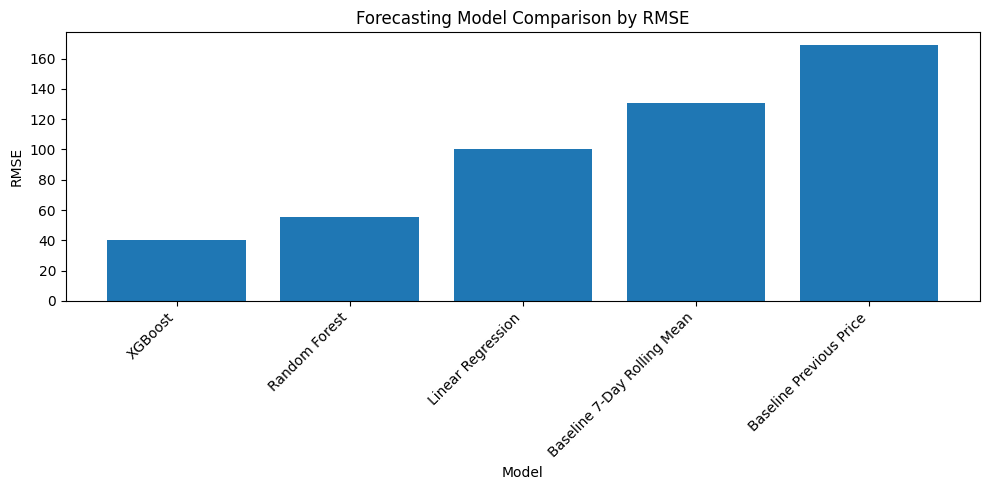

In [57]:
plt.figure(figsize=(10, 5))
plt.bar(model_comparison["model_name"], model_comparison["rmse"])
plt.title("Forecasting Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_model_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

## 23. Prepare Prediction Output

We prepare prediction results for each model.

This helps us compare actual and predicted prices visually.

In [58]:
prediction_results = test_data[["date", "price"]].copy()

asset_columns = [
    column for column in test_data.columns
    if column.startswith("asset_")
]

if asset_columns:
    prediction_results["asset"] = test_data[asset_columns].idxmax(axis=1)
    prediction_results["asset"] = prediction_results["asset"].str.replace("asset_", "", regex=False)
else:
    prediction_results["asset"] = "Unknown"

prediction_results = prediction_results.rename(columns={"price": "actual_price"})

prediction_results["baseline_previous_price"] = baseline_previous_predictions
prediction_results["baseline_rolling_mean"] = baseline_rolling_predictions
prediction_results["linear_regression_prediction"] = linear_predictions
prediction_results["random_forest_prediction"] = random_forest_predictions

if xgboost_predictions is not None:
    prediction_results["xgboost_prediction"] = xgboost_predictions

prediction_results["best_model_name"] = best_model_info["best_model"]

prediction_results.head()

,date,actual_price,asset,baseline_previous_price,baseline_rolling_mean,linear_regression_prediction,random_forest_prediction,xgboost_prediction,best_model_name
400,2023-10-04,414.1300,Stock A,422.0200,411.5843,454.9784,409.2511,419.7817,XGBoost
401,2023-10-04,145.0000,Stock A,414.1300,373.1957,304.3177,147.2329,159.1552,XGBoost
402,2023-10-05,240.0700,Bond A,402.3600,280.0614,301.0756,237.8056,242.5863,XGBoost
403,2023-10-05,66.1700,Commodity A,340.0700,282.5686,174.5903,68.5018,80.2864,XGBoost
404,2023-10-06,267.1300,Commodity A,66.1700,278.2957,367.6201,371.4593,338.6776,XGBoost


## 24. Actual vs Predicted Visualization

We plot actual prices against model predictions.

This helps us visually inspect model performance.

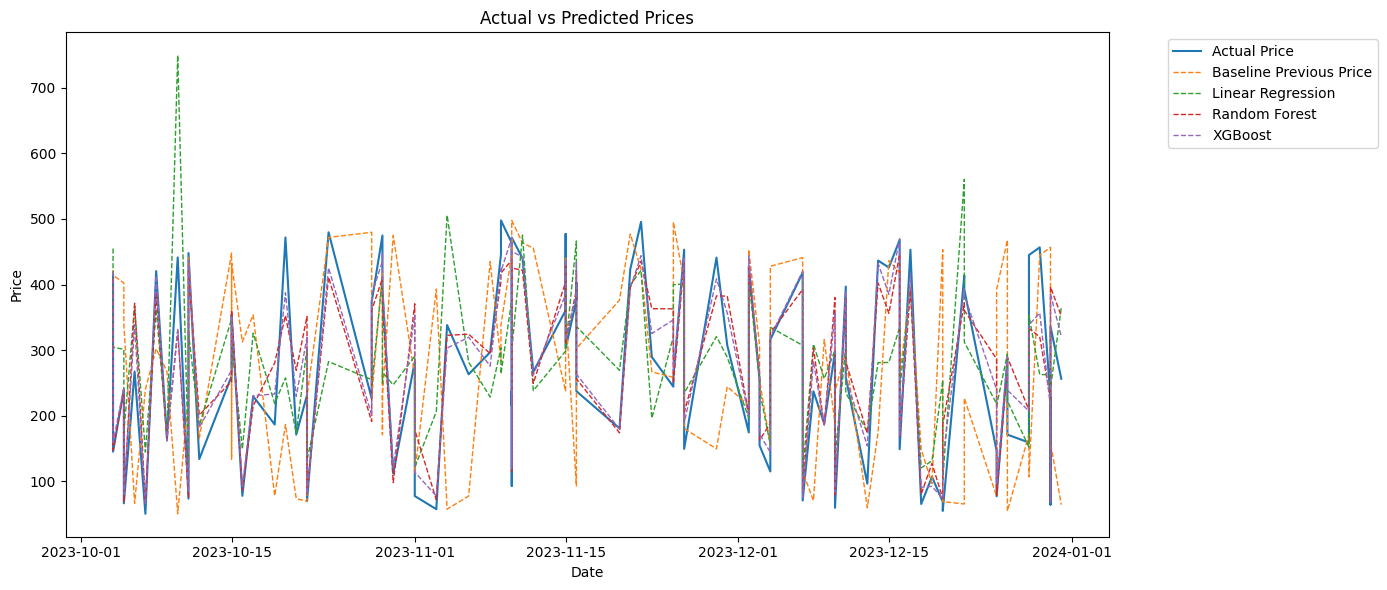

In [59]:
plt.figure(figsize=(14, 6))

plot_data = prediction_results.sort_values("date").copy()

plt.plot(
    plot_data["date"],
    plot_data["actual_price"],
    linewidth=1.5,
    label="Actual Price"
)

plt.plot(
    plot_data["date"],
    plot_data["baseline_previous_price"],
    linestyle="--",
    linewidth=1,
    label="Baseline Previous Price"
)

plt.plot(
    plot_data["date"],
    plot_data["linear_regression_prediction"],
    linestyle="--",
    linewidth=1,
    label="Linear Regression"
)

plt.plot(
    plot_data["date"],
    plot_data["random_forest_prediction"],
    linestyle="--",
    linewidth=1,
    label="Random Forest"
)

if "xgboost_prediction" in plot_data.columns:
    plt.plot(
        plot_data["date"],
        plot_data["xgboost_prediction"],
        linestyle="--",
        linewidth=1,
        label="XGBoost"
    )

plt.title("Actual vs Predicted Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_actual_vs_predicted_prices.png", dpi=300, bbox_inches="tight")
plt.show()

## 25. Asset-wise Actual vs Predicted

We create separate actual vs predicted charts for each asset.

This makes interpretation easier.

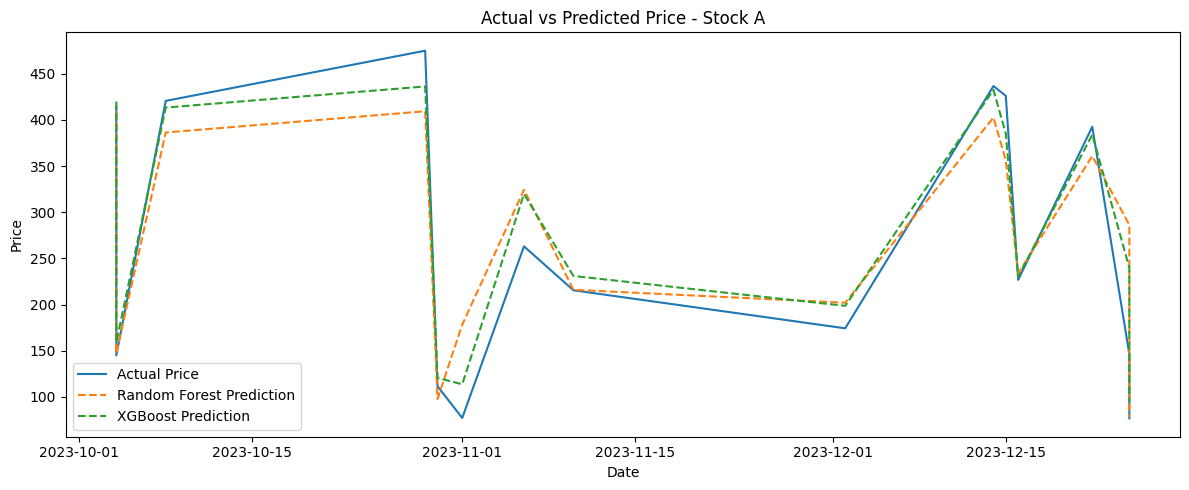

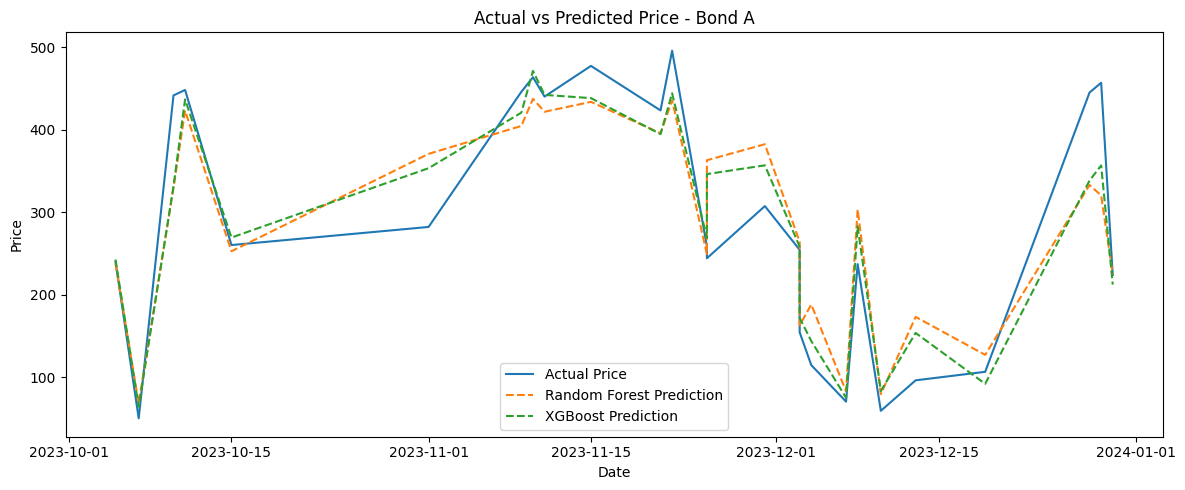

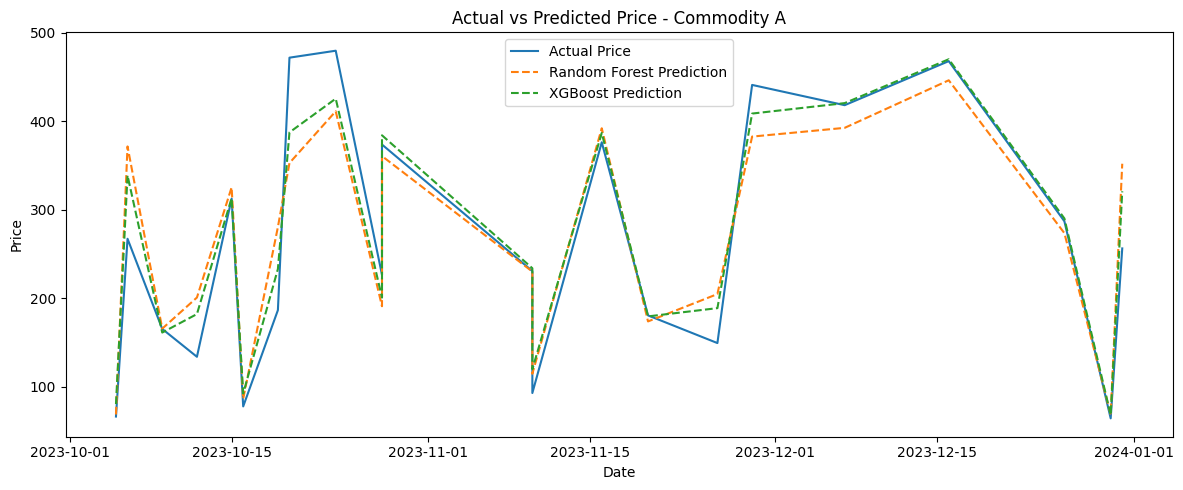

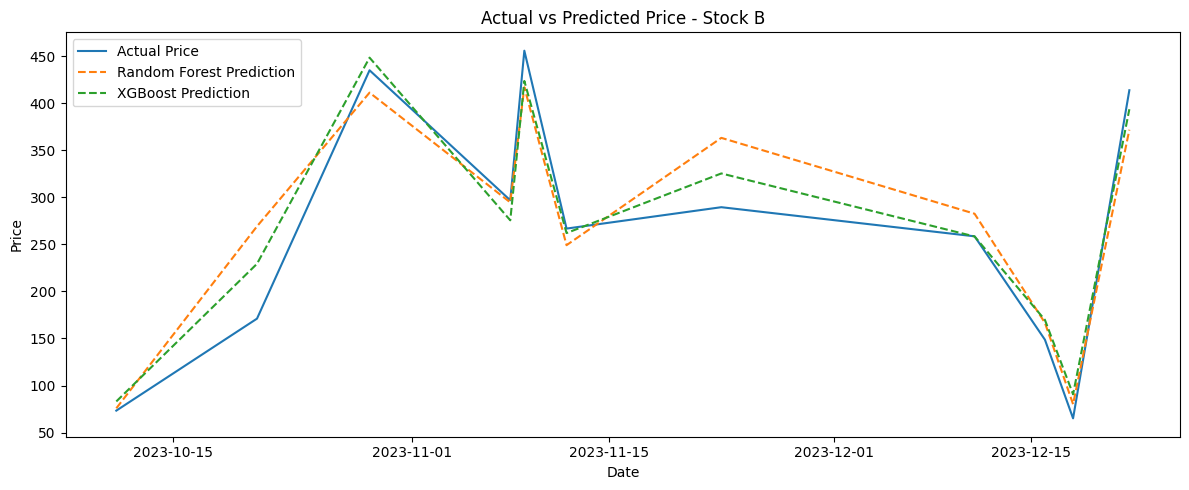

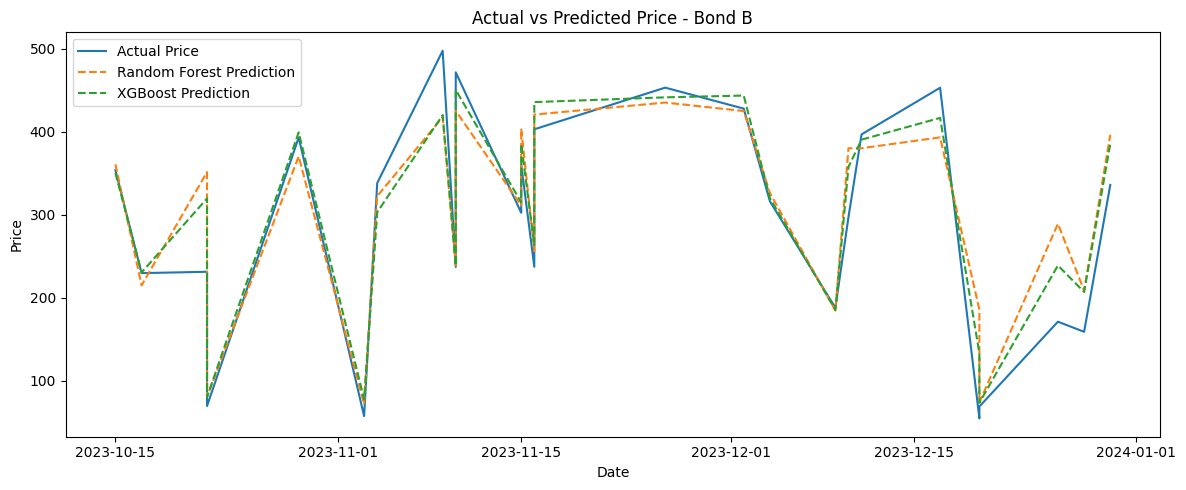

In [60]:
for asset in prediction_results["asset"].unique():
    asset_data = prediction_results[prediction_results["asset"] == asset].sort_values("date")

    plt.figure(figsize=(12, 5))

    plt.plot(
        asset_data["date"],
        asset_data["actual_price"],
        linewidth=1.5,
        label="Actual Price"
    )

    plt.plot(
        asset_data["date"],
        asset_data["random_forest_prediction"],
        linestyle="--",
        linewidth=1.5,
        label="Random Forest Prediction"
    )

    if "xgboost_prediction" in asset_data.columns:
        plt.plot(
            asset_data["date"],
            asset_data["xgboost_prediction"],
            linestyle="--",
            linewidth=1.5,
            label="XGBoost Prediction"
        )

    plt.title(f"Actual vs Predicted Price - {asset}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()

    safe_asset_name = str(asset).replace(" ", "_").replace("/", "_").lower()
    plt.savefig(
        FIGURES_DIR / f"03_actual_vs_predicted_{safe_asset_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 26. Feature Importance

For Random Forest, we can inspect which features were most important for price prediction.

In [61]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,feature,importance
0,daily_return,0.6388
1,price_rolling_mean_7,0.1301
2,price_lag_1,0.1033
3,price_rolling_std_7,0.0205
4,price_rolling_mean_14,0.0148
5,price_lag_3,0.0136
6,price_rolling_std_14,0.0114
7,return_rolling_volatility_14,0.0100
8,return_rolling_volatility_7,0.0085
9,price_lag_14,0.0073


## 27. Visualize Feature Importance

This chart shows the top features used by the Random Forest model.

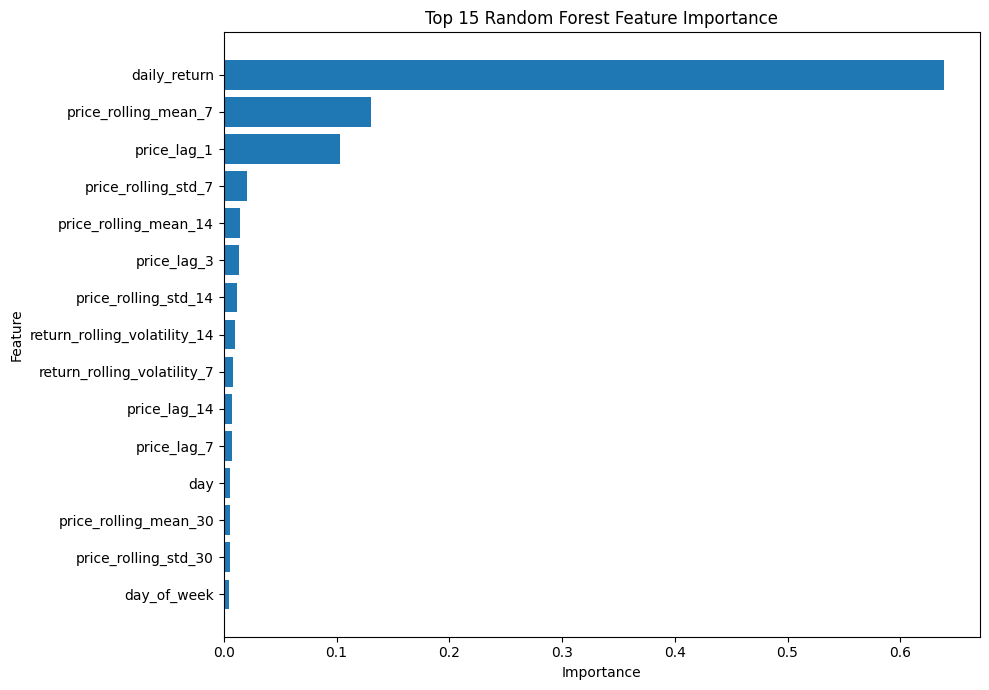

In [62]:
top_n = 15

top_features = feature_importance.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 28. Future Forecasting Preparation

Now we create a simple future forecast using the best available model from this notebook.

For this notebook experiment, we use the Random Forest model because it is available without extra dependencies and can use engineered features.

The future forecast is generated recursively:

1. Take recent history for each asset
2. Create next date
3. Predict next price
4. Add predicted row back into history
5. Repeat for 30 future steps

In [28]:
def recursive_random_forest_forecast(
    historical_dataframe,
    model,
    feature_columns,
    forecast_steps=30
):
    """
    Generate recursive Random Forest forecasts for each asset.

    Args:
        historical_dataframe (pd.DataFrame): Historical data with date, asset, price.
        model: Trained Random Forest model.
        feature_columns (list): Feature column names.
        forecast_steps (int): Number of future steps.

    Returns:
        pd.DataFrame: Future forecast dataframe.
    """
    history = historical_dataframe[["date", "asset", "price"]].copy()
    history = history.sort_values(["asset", "date"]).reset_index(drop=True)

    forecast_rows = []

    for asset in history["asset"].unique():
        asset_history = history[history["asset"] == asset].copy()
        last_date = asset_history["date"].max()

        for step in range(1, forecast_steps + 1):
            future_date = last_date + pd.Timedelta(days=step)

            temporary_row = pd.DataFrame({
                "date": [future_date],
                "asset": [asset],
                "price": [asset_history["price"].iloc[-1]]
            })

            temporary_history = pd.concat(
                [asset_history, temporary_row],
                ignore_index=True
            )

            temporary_features = create_forecasting_features(temporary_history)

            temporary_model_data = pd.get_dummies(
                temporary_features,
                columns=["asset"],
                drop_first=False,
                dtype=int
            )

            latest_row = temporary_model_data.tail(1).copy()

            for column in feature_columns:
                if column not in latest_row.columns:
                    latest_row[column] = 0

            X_future = latest_row[feature_columns]

            predicted_price = model.predict(X_future)[0]
            predicted_price = max(float(predicted_price), 0.0)

            forecast_rows.append({
                "date": future_date,
                "asset": asset,
                "forecasted_price": predicted_price,
                "model_name": "Random Forest"
            })

            new_history_row = pd.DataFrame({
                "date": [future_date],
                "asset": [asset],
                "price": [predicted_price]
            })

            asset_history = pd.concat(
                [asset_history, new_history_row],
                ignore_index=True
            )

    return pd.DataFrame(forecast_rows)


future_forecast = recursive_random_forest_forecast(
    historical_dataframe=df,
    model=random_forest_model,
    feature_columns=feature_columns,
    forecast_steps=30
)

future_forecast.head()

,date,asset,forecasted_price,model_name
0,2023-12-31,Bond A,215.8892,Random Forest
1,2024-01-01,Bond A,262.2365,Random Forest
2,2024-01-02,Bond A,361.9324,Random Forest
3,2024-01-03,Bond A,386.9119,Random Forest
4,2024-01-04,Bond A,402.8854,Random Forest


## 29. Visualize Future Forecast

We plot historical prices and future forecasted prices.

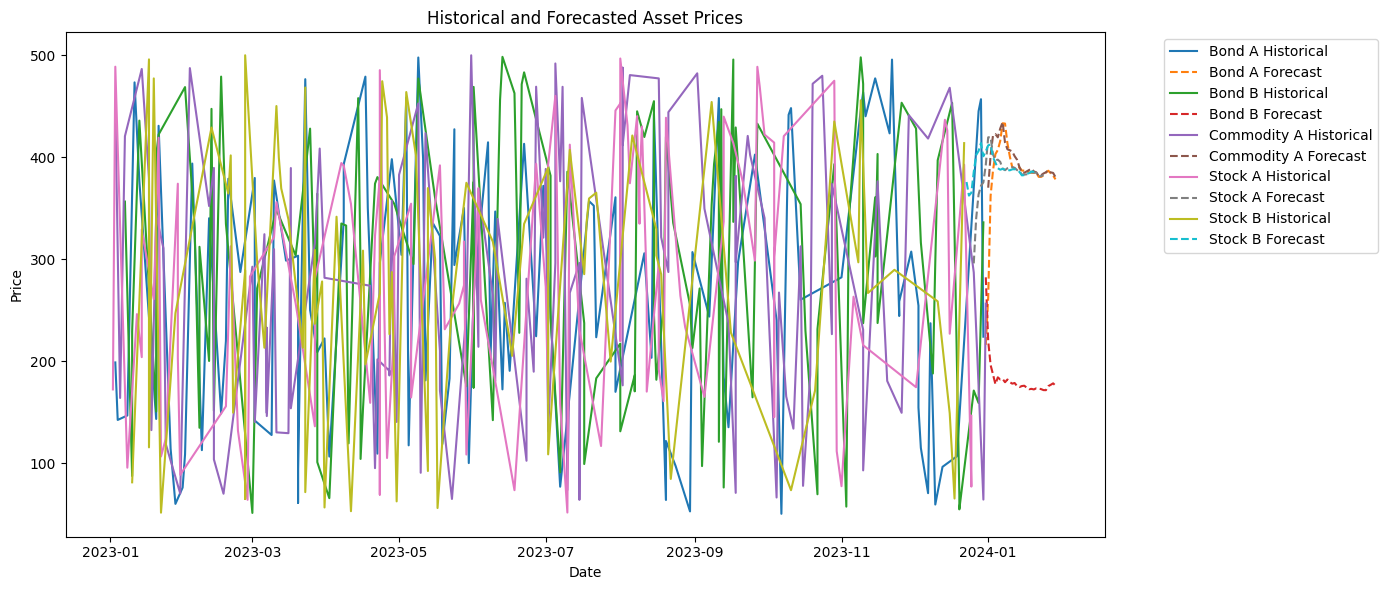

In [29]:
plt.figure(figsize=(14, 6))

for asset in df["asset"].unique():
    historical_asset = df[df["asset"] == asset].sort_values("date")
    forecast_asset = future_forecast[future_forecast["asset"] == asset].sort_values("date")

    plt.plot(
        historical_asset["date"],
        historical_asset["price"],
        linewidth=1.5,
        label=f"{asset} Historical"
    )

    plt.plot(
        forecast_asset["date"],
        forecast_asset["forecasted_price"],
        linestyle="--",
        linewidth=1.5,
        label=f"{asset} Forecast"
    )

plt.title("Historical and Forecasted Asset Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_future_forecast_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

## 30. Save Forecasting Experiment Outputs

We save:

- Dataset summary
- Asset summary
- Model comparison metrics
- Prediction results
- Feature importance
- Future forecast
- Best model information

In [30]:
dataset_summary_df.to_csv(TABLES_DIR / "03_dataset_summary.csv", index=False)
asset_summary.to_csv(TABLES_DIR / "03_asset_summary.csv", index=False)
model_comparison.to_csv(TABLES_DIR / "03_forecasting_model_comparison.csv", index=False)
prediction_results.to_csv(OUTPUTS_DIR / "03_forecasting_predictions.csv", index=False)
feature_importance.to_csv(TABLES_DIR / "03_random_forest_feature_importance.csv", index=False)
future_forecast.to_csv(OUTPUTS_DIR / "03_random_forest_future_forecast.csv", index=False)

with open(TABLES_DIR / "03_best_forecasting_model.json", "w", encoding="utf-8") as file:
    json.dump(best_model_info, file, indent=4)

with open(TABLES_DIR / "03_forecasting_metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics_list, file, indent=4)

print("Saved forecasting experiment outputs:")
print(TABLES_DIR / "03_dataset_summary.csv")
print(TABLES_DIR / "03_asset_summary.csv")
print(TABLES_DIR / "03_forecasting_model_comparison.csv")
print(OUTPUTS_DIR / "03_forecasting_predictions.csv")
print(TABLES_DIR / "03_random_forest_feature_importance.csv")
print(OUTPUTS_DIR / "03_random_forest_future_forecast.csv")
print(TABLES_DIR / "03_best_forecasting_model.json")
print(TABLES_DIR / "03_forecasting_metrics.json")

Saved forecasting experiment outputs:
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\03_dataset_summary.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\03_asset_summary.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\03_forecasting_model_comparison.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\outputs\03_forecasting_predictions.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\03_random_forest_feature_importance.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\outputs\03_random_forest_future_forecast.csv
e:\VS CODE\The Developer's Arena

## 31. ARIMA Training

This uses project file:

```text
src/models/arima_model.py

In [31]:
try:
    import sys

    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from src.models.arima_model import ARIMAForecaster

    arima_forecaster = ARIMAForecaster(
        order=(5, 1, 0),
        date_column="date",
        asset_column="asset",
        target_column="price",
        frequency="D",
        test_size=0.2
    )

    arima_summary = arima_forecaster.train_forecast_save(
        dataframe=df,
        forecast_steps=30
    )

    print("ARIMA training completed.")
    arima_summary

except Exception as error:
    print("ARIMA training skipped.")
    print("Reason:", error)

2026-06-08 12:40:29,505 - src.monitoring.logger - WARNING - Failed to load logging configuration from E:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\config\logging.yaml. Using basic logging instead. Error: Unable to configure handler 'api_file'
2026-06-08 12:40:29,507 - financial_portfolio - INFO - Starting ARIMA training process.
2026-06-08 12:40:29,515 - financial_portfolio - INFO - Training ARIMA model for asset: Bond A
2026-06-08 12:40:29,658 - financial_portfolio - INFO - ARIMA model trained successfully for asset: Bond A
2026-06-08 12:40:29,666 - financial_portfolio - INFO - ARIMA metrics for Bond A: {'mae': 117.492363, 'mse': 19880.693688, 'rmse': 140.998914, 'mape': 81.79381, 'r2_score': -0.064803, 'train_records': 289, 'test_records': 73}
2026-06-08 12:40:29,674 - financial_portfolio - INFO - Training ARIMA model for asset: Bond B
2026-06-08 12:40:29,732 - financial_portfolio - INFO - ARIMA model trained successfu

ARIMA training completed.


## 32. XGBoost Project Model Training

This uses project file:

```text
src/models/xgboost_model.py

In [32]:
try:
    import sys

    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from src.models.xgboost_model import XGBoostForecaster

    project_xgb_forecaster = XGBoostForecaster(
        date_column="date",
        asset_column="asset",
        target_column="price",
        test_size=0.2,
        lag_periods=[1, 3, 7, 14],
        rolling_windows=[7, 14, 30]
    )

    project_xgb_summary = project_xgb_forecaster.train_forecast_save(
        dataframe=df,
        forecast_steps=30
    )

    print("Project XGBoost training completed.")
    project_xgb_summary

except Exception as error:
    print("Project XGBoost training skipped.")
    print("Reason:", error)

2026-06-08 12:40:30,295 - financial_portfolio - INFO - Starting XGBoost model training.
2026-06-08 12:40:31,023 - financial_portfolio - INFO - XGBoost model training completed.
2026-06-08 12:40:31,024 - financial_portfolio - INFO - XGBoost metrics: {'mae': 29.615809, 'mse': 1620.766791, 'rmse': 40.258748, 'mape': 14.915182, 'r2_score': 0.916421, 'feature_count': 29}
2026-06-08 12:40:31,033 - financial_portfolio - INFO - XGBoost model saved at: E:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\models\xgboost_model.pkl
2026-06-08 12:40:31,036 - financial_portfolio - INFO - XGBoost feature columns saved at: E:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\models\xgboost_feature_columns.json
2026-06-08 12:40:31,038 - financial_portfolio - INFO - XGBoost metrics JSON saved at: E:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_a

Project XGBoost training completed.


## 33. Prophet Training

This uses project file:

```text
src/models/prophet_model.py

In [33]:
try:
    import sys

    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from src.models.prophet_model import ProphetForecaster

    prophet_forecaster = ProphetForecaster(
        date_column="date",
        asset_column="asset",
        target_column="price",
        test_size=0.2,
        frequency="D",
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    prophet_summary = prophet_forecaster.train_forecast_save(
        dataframe=df,
        forecast_periods=30
    )

    print("Prophet training completed.")
    prophet_summary

except Exception as error:
    print("Prophet optional training skipped.")
    print("Reason:", error)

2026-06-08 12:40:47,736 - prophet.plot - ERROR - Importing plotly failed. Interactive plots will not work.
2026-06-08 12:40:47,739 - financial_portfolio - INFO - Starting Prophet training process.
2026-06-08 12:40:47,755 - financial_portfolio - INFO - Training Prophet model for asset: Bond A
2026-06-08 12:40:47,927 - cmdstanpy - INFO - Chain [1] start processing
2026-06-08 12:40:48,284 - cmdstanpy - INFO - Chain [1] done processing
2026-06-08 12:40:48,296 - financial_portfolio - INFO - Prophet model trained successfully for asset: Bond A
2026-06-08 12:40:48,362 - financial_portfolio - INFO - Prophet metrics for Bond A: {'mae': 5653.382457, 'mse': 49119726.855649, 'rmse': 7008.546701, 'mape': 2272.293019, 'r2_score': -2211.237131, 'train_records': 80, 'test_records': 20}
2026-06-08 12:40:48,381 - financial_portfolio - INFO - Training Prophet model for asset: Bond B
2026-06-08 12:40:48,503 - cmdstanpy - INFO - Chain [1] start processing
2026-06-08 12:40:48,745 - cmdstanpy - INFO - Chain 

Prophet training completed.


## 34. LSTM Training

This uses your project file:

```text
src/models/lstm_model.py

In [34]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [35]:
try:
    import sys

    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from src.models.lstm_model import LSTMForecaster

    lstm_forecaster = LSTMForecaster(
        date_column="date",
        asset_column="asset",
        target_column="price",
        frequency="D",
        sequence_length=10,
        test_size=0.2,
        epochs=5,
        batch_size=16,
        random_state=42
    )

    lstm_summary = lstm_forecaster.train_forecast_save(
        dataframe=df,
        forecast_steps=30
    )

    print("LSTM training completed.")
    lstm_summary

except Exception as error:
    print("LSTM optional training skipped.")
    print("Reason:", error)

LSTM optional training skipped.
Reason: TensorFlow is required for LSTM modeling. Install it using: pip install tensorflow


## 35. Final Forecasting Experiment Summary

### What We Completed

In this notebook, we:

- Loaded and cleaned the financial asset price dataset
- Created calendar, return, lag, and rolling features
- Performed time-based train-test split
- Built baseline forecasting models
- Trained Linear Regression
- Trained Random Forest
- Optionally trained XGBoost
- Compared forecasting models using MAE, RMSE, MAPE, and R2 score
- Selected the best model using RMSE
- Created future forecasts
- Saved prediction outputs, metrics, and charts

### Key Outputs

```text
reports/tables/03_forecasting_model_comparison.csv
outputs/03_forecasting_predictions.csv
outputs/03_random_forest_future_forecast.csv
reports/tables/03_best_forecasting_model.json
reports/figures/03_model_comparison_rmse.png
reports/figures/03_actual_vs_predicted_prices.png
reports/figures/03_future_forecast_random_forest.png